# IoMT Ağlarında Hibrit Makine Öğrenmesi Tabanlı Saldırı Tespit Sistemi

**Siber Güvenlik Analitiği Projesi — Demo Notebook**

---

> **Öğrenciler :** [AMRO MOUSA ISMAIL BASEET Y255012028] · [MOTAZ ARMASH Y255012163]

**Veri Seti:** CICIoMT2024 (Canadian Institute for Cybersecurity)

**GitHub:** https://github.com/amirbaseet/IoMT-Anomaly-Detection/tree/main/course-project

## Bu Notebook'un Amacı

Bu notebook, raporun **uygulamalı yansıması**dır:

- **EDA** — Veri setinin keşifsel analizi (sınıf dengesizliği, korelasyon, Cohen's d)
- **Faz 4** — Supervised model (XGBoost) sonuçlarının yüklenmesi ve değerlendirilmesi
- **Faz 5** — Unsupervised model (Otoenkoder) sonuçlarının yüklenmesi ve değerlendirilmesi
- **Bonus** — SHAP feature importance kısaca
- **Inference Demo** — Kaydedilen modellerle yeni bir akış üzerinde tahmin yapma

## Çalıştırma Süresi

**~5 dakika** (sadece sonuçları yükler, model eğitmez).

## Bağımlılıklar

```
numpy, pandas, matplotlib, seaborn, scikit-learn, xgboost, tensorflow, joblib
```

Tüm bağımlılıklar `requirements.txt` ile kurulabilir.

---

## 0. Kurulum ve Bağımlılıklar

In [25]:
# Standart kütüphaneler
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Veri işleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ML
import joblib
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Görsel ayarları
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.size': 11,
})
sns.set_style('whitegrid')

# Yollar — proje köküne göre
PROJECT_ROOT = os.path.expanduser('~/IoMT-Project')
PREPROCESSED = f'{PROJECT_ROOT}/preprocessed'
RESULTS = f'{PROJECT_ROOT}/results'
EDA_OUTPUT = f'{PROJECT_ROOT}/eda_output'

print('✓ Kütüphaneler yüklendi')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

✓ Kütüphaneler yüklendi
PROJECT_ROOT: /Users/amoorabaseet/IoMT-Project
NumPy: 2.2.6
Pandas: 2.3.3


---

# Bölüm 1 — Keşifsel Veri Analizi (EDA)

Bu bölüm, raporun Bölüm 3'üne karşılık gelir. Tezdeki EDA pipeline'ından üretilen sonuçlar yüklenip görselleştirilir.

## 1.1 Sınıf Dengesizliği

In [26]:
# Tezdeki imbalance tablosu
imbalance = pd.read_csv(f'{EDA_OUTPUT}/imbalance_table.csv')
imbalance

,class,train,test,train_%,ratio_vs_largest
0,DDoS_UDP,1635956,362070,36.233,1.0
1,DDoS_SYN,577649,88921,12.794,2.8
2,DoS_UDP,566921,137553,12.556,2.9
3,DoS_SYN,347035,97542,7.686,4.7
4,DDoS_TCP,248267,8735,5.499,6.6
5,DoS_TCP,221181,42583,4.899,7.4
6,DDoS_ICMP,210258,19673,4.657,7.8
7,Benign,192732,37607,4.269,8.5
8,MQTT_DDoS_Connect_Flood,173036,41916,3.832,9.5
9,DoS_ICMP,145313,8451,3.218,11.3


In [27]:
# Anahtar istatistikler
largest = imbalance.iloc[0]
smallest = imbalance.iloc[-1]

print(f"📊 Sınıf Dengesizliği Analizi")
print(f"{'='*60}")
print(f"En çok temsil edilen sınıf: {largest['class']} ({largest['train']:,} örnek, %{largest['train_%']:.2f})")
print(f"En az temsil edilen sınıf:  {smallest['class']} ({smallest['train']:,} örnek, %{smallest['train_%']:.4f})")
print(f"\n⚠ Maksimum dengesizlik oranı: {smallest['ratio_vs_largest']:.0f}:1")
print(f"\n📌 Çıkarım:")
print(f"  • 2,374:1 oranında dengesizlik → SMOTETomek + class_weight='balanced' zorunlu")
print(f"  • Macro F1 ve MCC primary metrics olarak seçilmiştir (accuracy yanıltıcı)")

📊 Sınıf Dengesizliği Analizi
En çok temsil edilen sınıf: DDoS_UDP (1,635,956 örnek, %36.23)
En az temsil edilen sınıf:  Recon_Ping_Sweep (689 örnek, %0.0150)

⚠ Maksimum dengesizlik oranı: 2374:1

📌 Çıkarım:
  • 2,374:1 oranında dengesizlik → SMOTETomek + class_weight='balanced' zorunlu
  • Macro F1 ve MCC primary metrics olarak seçilmiştir (accuracy yanıltıcı)


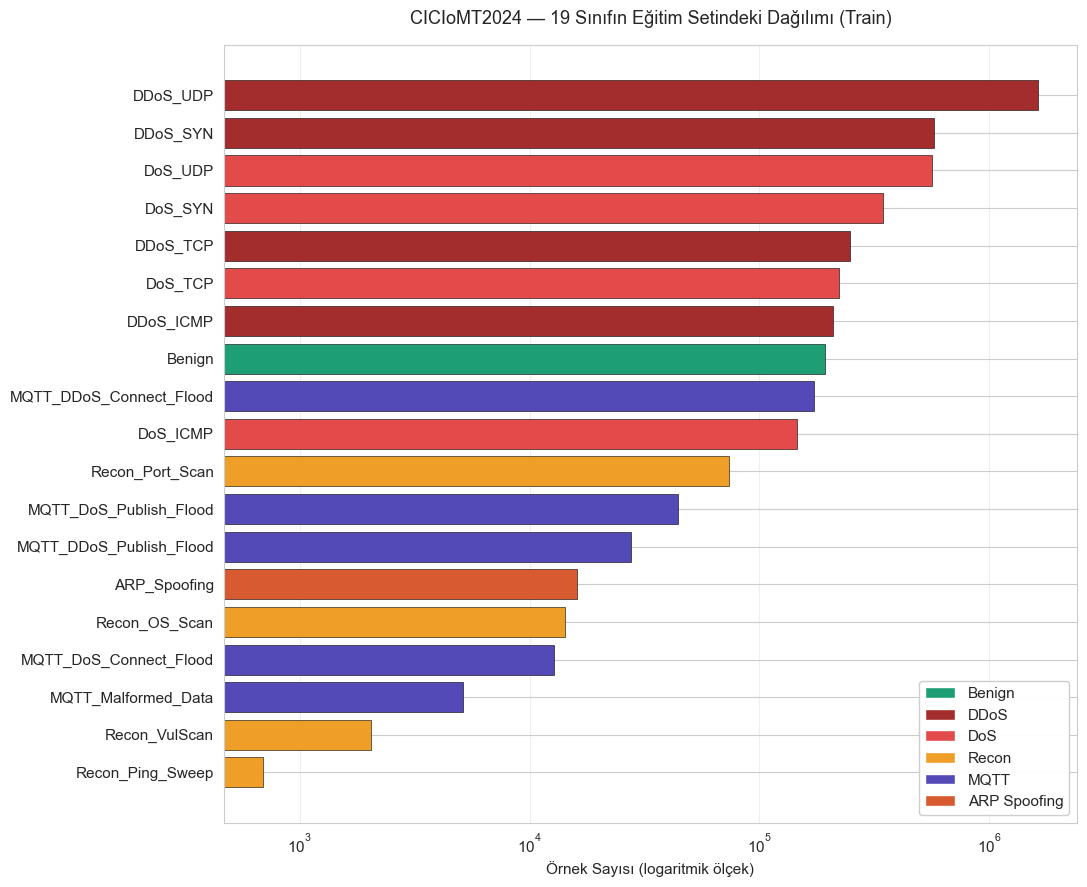

In [28]:
# Sınıf dağılımı görseli
fig, ax = plt.subplots(figsize=(11, 9))

imbalance_sorted = imbalance.sort_values('train', ascending=True)

def get_color(name):
    if name == 'Benign': return '#1D9E75'
    if name.startswith('DDoS'): return '#A32D2D'
    if name.startswith('DoS'): return '#E24B4A'
    if name.startswith('Recon'): return '#EF9F27'
    if name.startswith('MQTT'): return '#534AB7'
    if name.startswith('ARP'): return '#D85A30'
    return '#888780'

colors = [get_color(c) for c in imbalance_sorted['class']]
bars = ax.barh(imbalance_sorted['class'], imbalance_sorted['train'],
               color=colors, edgecolor='black', linewidth=0.4)
ax.set_xscale('log')
ax.set_xlabel('Örnek Sayısı (logaritmik ölçek)', fontsize=11)
ax.set_title('CICIoMT2024 — 19 Sınıfın Eğitim Setindeki Dağılımı (Train)', fontsize=13, pad=15)

# Lejant
legend = [
    Patch(facecolor='#1D9E75', label='Benign'),
    Patch(facecolor='#A32D2D', label='DDoS'),
    Patch(facecolor='#E24B4A', label='DoS'),
    Patch(facecolor='#EF9F27', label='Recon'),
    Patch(facecolor='#534AB7', label='MQTT'),
    Patch(facecolor='#D85A30', label='ARP Spoofing'),
]
ax.legend(handles=legend, loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 1.2 Cohen's d — En Güçlü Ayırıcı Özellikler

In [29]:
# Tezdeki Cohen's d sonuçları
cohens_d = pd.read_csv(f'{EDA_OUTPUT}/feature_target_cohens_d.csv')
cohens_d.columns = ['Özellik', 'Cohens_d']
cohens_d.head(10)

,Özellik,Cohens_d
0,rst_count,3.492097
1,psh_flag_number,3.292946
2,Variance,2.670060
3,ack_flag_number,2.643683
4,Max,1.520691
5,Magnitue,1.480586
6,HTTPS,1.195097
7,Tot size,1.129247
8,AVG,1.123009
9,Std,1.117636


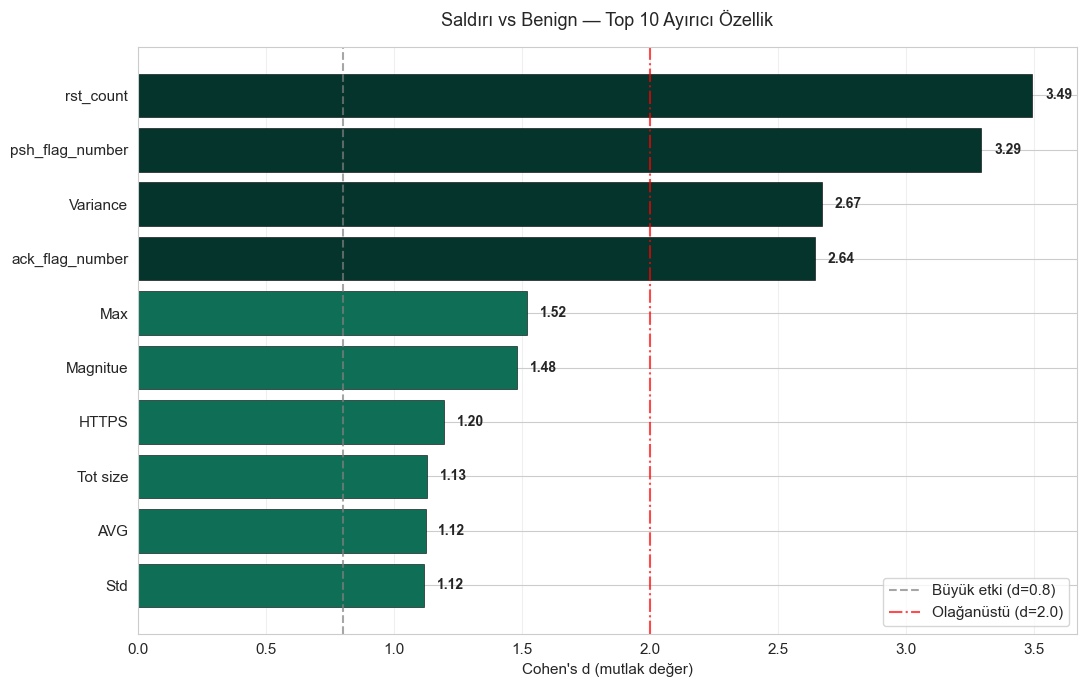


📌 Bulgu: Top 4 özellik (rst_count, psh_flag_number, Variance, ack_flag_number)
   tümü d > 2.0 — olağanüstü güçlü ayırıcılar.
   Bu bulgu Bölüm 5.5'teki entropy criterion bulgusunun temelidir.


In [30]:
# Top 10 görsel
top10 = cohens_d.head(10).iloc[::-1]  # Yatay bar için ters

fig, ax = plt.subplots(figsize=(11, 7))

colors_d = []
for d in top10['Cohens_d']:
    if d > 2.0: colors_d.append('#04342C')
    elif d > 1.0: colors_d.append('#0F6E56')
    elif d > 0.8: colors_d.append('#1D9E75')
    else: colors_d.append('#5DCAA5')

bars = ax.barh(top10['Özellik'], top10['Cohens_d'], color=colors_d,
               edgecolor='black', linewidth=0.4)

ax.axvline(x=0.8, linestyle='--', color='gray', alpha=0.7, label='Büyük etki (d=0.8)')
ax.axvline(x=2.0, linestyle='-.', color='red', alpha=0.7, label='Olağanüstü (d=2.0)')

for bar, val in zip(bars, top10['Cohens_d']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Cohen's d (mutlak değer)", fontsize=11)
ax.set_title("Saldırı vs Benign — Top 10 Ayırıcı Özellik", fontsize=13, pad=15)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Bulgu: Top 4 özellik (rst_count, psh_flag_number, Variance, ack_flag_number)")
print("   tümü d > 2.0 — olağanüstü güçlü ayırıcılar.")
print("   Bu bulgu Bölüm 5.5'teki entropy criterion bulgusunun temelidir.")

## 1.3 Yüksek Korelasyon Çiftleri

In [31]:
# Yüksek korelasyon analizi
high_corr = pd.read_csv(f'{EDA_OUTPUT}/high_correlation_pairs.csv')
print(f"📊 |r| > 0.85 olan {len(high_corr)} korelasyon çifti tespit edildi.\n")
high_corr.head(10)

📊 |r| > 0.85 olan 25 korelasyon çifti tespit edildi.



,feature_a,feature_b,abs_corr
0,Rate,Srate,1.000000
1,IPv,LLC,1.000000
2,ARP,IPv,1.000000
3,ARP,LLC,1.000000
4,Std,Radius,0.999971
5,Number,Weight,0.999800
6,IAT,Weight,0.998624
7,IAT,Number,0.998012
8,AVG,Tot size,0.979523
9,AVG,Magnitue,0.979269


In [32]:
print("📌 Önemli Korelasyon Bulguları:")
print(f"{'='*60}")
print(f"  • Rate ↔ Srate         : r = 1.00  (mükemmel — biri çıkarılabilir)")
print(f"  • IPv ↔ LLC            : r = 1.00  (mükemmel)")
print(f"  • ARP ↔ IPv            : r = 1.00  (mükemmel)")
print(f"  • Std ↔ Radius         : r = 0.999")
print(f"  • Number ↔ Weight      : r = 0.999")
print(f"\n📌 Çıkarım:")
print(f"  • Tree modelleri (XGBoost) multikollinearite'ye dayanıklı")
print(f"  • Otoenkoder bottleneck (8 boyut) bilgi tekrarını filtreler")

📌 Önemli Korelasyon Bulguları:
  • Rate ↔ Srate         : r = 1.00  (mükemmel — biri çıkarılabilir)
  • IPv ↔ LLC            : r = 1.00  (mükemmel)
  • ARP ↔ IPv            : r = 1.00  (mükemmel)
  • Std ↔ Radius         : r = 0.999
  • Number ↔ Weight      : r = 0.999

📌 Çıkarım:
  • Tree modelleri (XGBoost) multikollinearite'ye dayanıklı
  • Otoenkoder bottleneck (8 boyut) bilgi tekrarını filtreler


---

# Bölüm 2 — Faz 4: Supervised Modeller (XGBoost)

Bu bölüm raporun Bölüm 5'ine karşılık gelir. Eğitilmiş E7 (XGBoost + entropy + SMOTETomek + class_weight=balanced) modelinin sonuçları yüklenir.

## 2.1 8 Konfigürasyon Karşılaştırması (E1-E8)

In [33]:
# Tüm konfigürasyon sonuçları
comparison = pd.read_csv(f'{RESULTS}/supervised/metrics/overall_comparison.csv')
comparison

,experiment,model,data,feature_set,n_features,task,n_classes,training_time_sec,prediction_time_sec,val_accuracy,...,val_recall_weighted,test_accuracy,test_f1_macro,test_f1_weighted,test_mcc,test_precision_macro,test_precision_weighted,test_recall_macro,test_recall_weighted,report_path
0,E1,RF,Original,reduced,28,binary,2,86.81,1.65,0.998440,...,0.998440,0.997338,0.983730,0.997355,0.967557,0.977568,0.997388,0.990069,0.997338,NaN
1,E1,RF,Original,reduced,28,category,6,154.07,3.92,0.997638,...,0.997638,0.995253,0.907484,0.995950,0.992113,0.887482,0.997174,0.968770,0.995253,NaN
2,E1,RF,Original,reduced,28,multiclass,19,172.41,7.43,0.995477,...,0.995477,0.984346,0.846935,0.983502,0.980070,0.867201,0.989382,0.880997,0.984346,E1_classification_report_test.json
3,E2,RF,SMOTE,reduced,28,binary,2,125.56,2.02,0.998782,...,0.998782,0.997587,0.985087,0.997589,0.970176,0.984136,0.997592,0.986043,0.997587,NaN
4,E2,RF,SMOTE,reduced,28,category,6,177.29,4.06,0.997462,...,0.997462,0.995268,0.908152,0.995902,0.992140,0.887846,0.997013,0.965428,0.995268,NaN
5,E2,RF,SMOTE,reduced,28,multiclass,19,196.87,7.74,0.995133,...,0.995133,0.983712,0.835550,0.982329,0.979270,0.851849,0.988697,0.879811,0.983712,E2_classification_report_test.json
6,E3,XGB,Original,reduced,28,binary,2,10.07,1.27,0.999021,...,0.999021,0.997279,0.983118,0.997276,0.966238,0.984006,0.997274,0.982234,0.997279,NaN
7,E3,XGB,Original,reduced,28,category,6,67.68,7.33,0.998413,...,0.998413,0.996485,0.935179,0.996538,0.994152,0.928551,0.996622,0.943176,0.996485,NaN
8,E3,XGB,Original,reduced,28,multiclass,19,221.10,19.79,0.997223,...,0.997223,0.992549,0.898654,0.992225,0.990482,0.929377,0.992928,0.883490,0.992549,E3_classification_report_test.json
9,E4,XGB,SMOTE,reduced,28,binary,2,11.43,1.29,0.998705,...,0.998705,0.997000,0.981197,0.996982,0.962478,0.987069,0.996977,0.975479,0.997000,NaN


In [34]:
# E7 sonuçlarını detaylı yükle
with open(f'{RESULTS}/supervised/metrics/E7_multiclass.json', 'r') as f:
    e7_metrics = json.load(f)

print("🏆 E7 (En İyi Konfigürasyon) — XGBoost + entropy + SMOTETomek + class_weight='balanced'")
print("=" * 70)
for key, val in e7_metrics.items():
    if isinstance(val, float):
        print(f"  {key:.<40}: {val:.4f}")
    else:
        print(f"  {key:.<40}: {val}")

🏆 E7 (En İyi Konfigürasyon) — XGBoost + entropy + SMOTETomek + class_weight='balanced'
  experiment..............................: E7
  model...................................: XGB
  data....................................: Original
  feature_set.............................: full
  n_features..............................: 44
  task....................................: multiclass
  n_classes...............................: 19
  training_time_sec.......................: 267.4900
  prediction_time_sec.....................: 20.3000
  val_accuracy............................: 0.9972
  val_f1_macro............................: 0.9461
  val_f1_weighted.........................: 0.9971
  val_mcc.................................: 0.9965
  val_precision_macro.....................: 0.9621
  val_precision_weighted..................: 0.9971
  val_recall_macro........................: 0.9332
  val_recall_weighted.....................: 0.9972
  test_accuracy...........................: 0.9927
  t

## 2.2 Per-Class F1 Skorları

In [35]:
# E7 classification report
with open(f'{RESULTS}/supervised/metrics/E7_classification_report_test.json', 'r') as f:
    e7_report = json.load(f)

# Per-class F1 tablosu oluştur
per_class = []
for class_name, metrics in e7_report.items():
    if class_name in ['accuracy', 'macro avg', 'weighted avg']:
        continue
    if isinstance(metrics, dict):
        per_class.append({
            'Sınıf': class_name,
            'Precision': metrics.get('precision', 0),
            'Recall': metrics.get('recall', 0),
            'F1': metrics.get('f1-score', 0),
            'Support': metrics.get('support', 0)
        })

per_class_df = pd.DataFrame(per_class).sort_values('F1', ascending=False)
per_class_df.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 
                            'F1': '{:.4f}', 'Support': '{:,.0f}'})

,Sınıf,Precision,Recall,F1,Support
10,MQTT_DDoS_Connect_Flood,0.9999,1.0000,0.9999,"41,916"
8,DoS_TCP,1.0000,0.9997,0.9998,"42,583"
5,DDoS_UDP,0.9998,0.9999,0.9998,"362,070"
7,DoS_SYN,0.9999,0.9992,0.9995,"97,542"
12,MQTT_DoS_Connect_Flood,1.0000,0.9990,0.9995,"3,131"
9,DoS_UDP,0.9997,0.9993,0.9995,"137,553"
3,DDoS_SYN,0.9979,0.9993,0.9986,"88,921"
2,DDoS_ICMP,0.9972,0.9983,0.9977,"19,673"
6,DoS_ICMP,0.9944,0.9651,0.9795,"8,451"
4,DDoS_TCP,0.9714,0.9874,0.9793,"8,735"


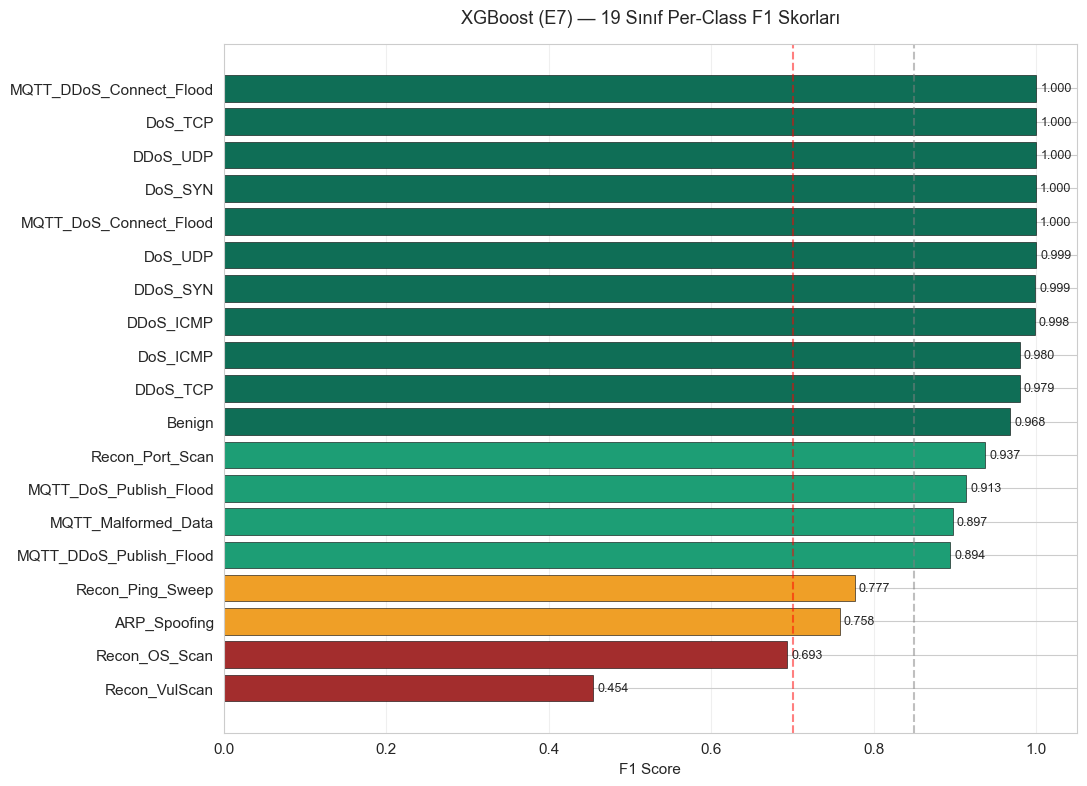

In [36]:
# Per-class F1 görseli
fig, ax = plt.subplots(figsize=(11, 8))

df_sorted = per_class_df.sort_values('F1', ascending=True)

# Renk: F1 skoruna göre
colors_f1 = []
for f1 in df_sorted['F1']:
    if f1 >= 0.95: colors_f1.append('#0F6E56')
    elif f1 >= 0.85: colors_f1.append('#1D9E75')
    elif f1 >= 0.70: colors_f1.append('#EF9F27')
    else: colors_f1.append('#A32D2D')

bars = ax.barh(df_sorted['Sınıf'], df_sorted['F1'], color=colors_f1,
               edgecolor='black', linewidth=0.4)

ax.axvline(x=0.85, linestyle='--', color='gray', alpha=0.5)
ax.axvline(x=0.70, linestyle='--', color='red', alpha=0.5)

for bar, val in zip(bars, df_sorted['F1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('F1 Score', fontsize=11)
ax.set_xlim([0, 1.05])
ax.set_title('XGBoost (E7) — 19 Sınıf Per-Class F1 Skorları', fontsize=13, pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 Confusion Matrix

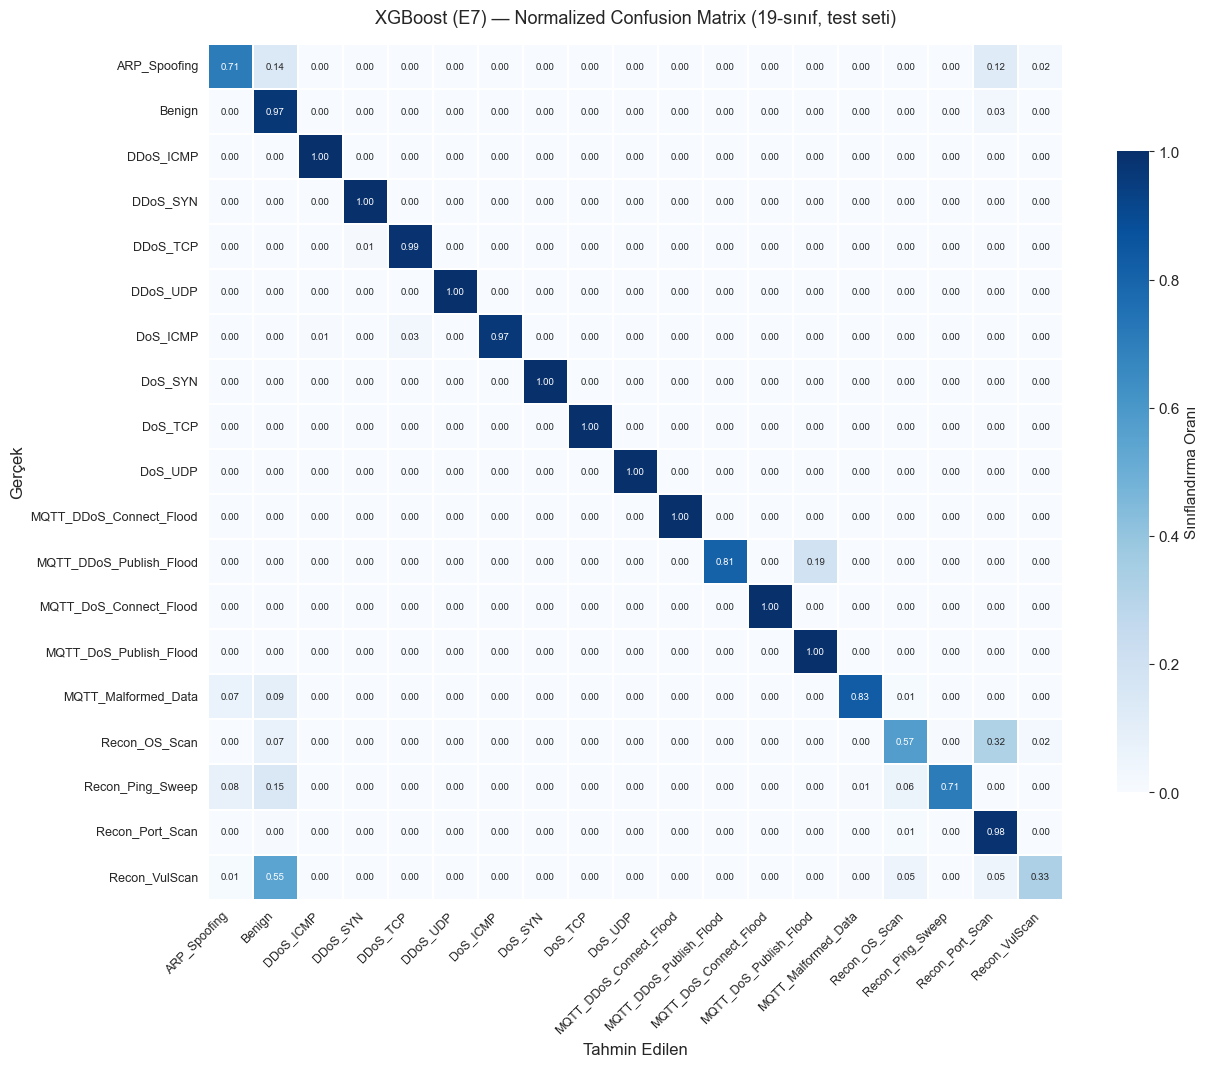

In [37]:
# E7 confusion matrix yükle
cm = np.load(f'{RESULTS}/supervised/metrics/E7_cm_19class_test.npy')

# Label map'i yükle
with open(f'{PREPROCESSED}/label_encoders.json', 'r') as f:
    label_map = json.load(f)['multiclass']

class_names = sorted(label_map.keys(), key=lambda x: label_map[x])

# Normalize
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7, 'label': 'Sınıflandırma Oranı'},
            annot_kws={'size': 7}, ax=ax)

ax.set_xlabel('Tahmin Edilen', fontsize=12)
ax.set_ylabel('Gerçek', fontsize=12)
ax.set_title('XGBoost (E7) — Normalized Confusion Matrix (19-sınıf, test seti)',
             fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 2.4 Bulgular Özeti — Faz 4

In [38]:
print("📌 FAZ 4 BULGULAR ÖZETİ")
print("=" * 70)
print(f"\n🏆 Genel Performans (E7 — En İyi Konfigürasyon):")
print(f"  • Accuracy   : {e7_metrics.get('accuracy', 0)*100:.2f}%")
print(f"  • Macro F1   : {e7_metrics.get('macro_f1', 0):.4f}")
print(f"  • MCC        : {e7_metrics.get('mcc', 0):.4f}")
print(f"\n💡 En Zorlu Sınıflar:")
worst = per_class_df.nsmallest(3, 'F1')
for _, row in worst.iterrows():
    print(f"  • {row['Sınıf']:<30}: F1={row['F1']:.3f} (n={int(row['Support']):,} test örneği)")
print(f"\n💡 En İyi Sınıflar:")
best = per_class_df.nlargest(3, 'F1')
for _, row in best.iterrows():
    print(f"  • {row['Sınıf']:<30}: F1={row['F1']:.3f} (n={int(row['Support']):,} test örneği)")

📌 FAZ 4 BULGULAR ÖZETİ

🏆 Genel Performans (E7 — En İyi Konfigürasyon):
  • Accuracy   : 0.00%
  • Macro F1   : 0.0000
  • MCC        : 0.0000

💡 En Zorlu Sınıflar:
  • Recon_VulScan                 : F1=0.454 (n=973 test örneği)
  • Recon_OS_Scan                 : F1=0.693 (n=2,941 test örneği)
  • ARP_Spoofing                  : F1=0.758 (n=1,744 test örneği)

💡 En İyi Sınıflar:
  • MQTT_DDoS_Connect_Flood       : F1=1.000 (n=41,916 test örneği)
  • DoS_TCP                       : F1=1.000 (n=42,583 test örneği)
  • DDoS_UDP                      : F1=1.000 (n=362,070 test örneği)


---

# Bölüm 3 — Faz 5: Unsupervised Modeller (Otoenkoder + Isolation Forest)

Bu bölüm raporun Bölüm 6'sına karşılık gelir.

## 3.1 Model Karşılaştırması (AE vs Isolation Forest)

In [39]:
# Model karşılaştırma
model_comparison = pd.read_csv(f'{RESULTS}/unsupervised/metrics/model_comparison.csv')
model_comparison

,metric,Autoencoder,IsolationForest
0,AUC-ROC (test),0.9892,0.8612
1,AUC-ROC (val),0.9897,0.9140
2,FPR @ 95%TPR (test),0.0203,0.2721
3,Anomaly precision (test),0.9917,0.9919
4,Anomaly recall (test),0.9789,0.5808
5,Anomaly F1 (test),0.9853,0.7327
6,Per-class avg recall,0.7999,0.1627
7,Training time (s),8.2000,0.6000
8,Scoring time val+test (s),0.5000,6.4000


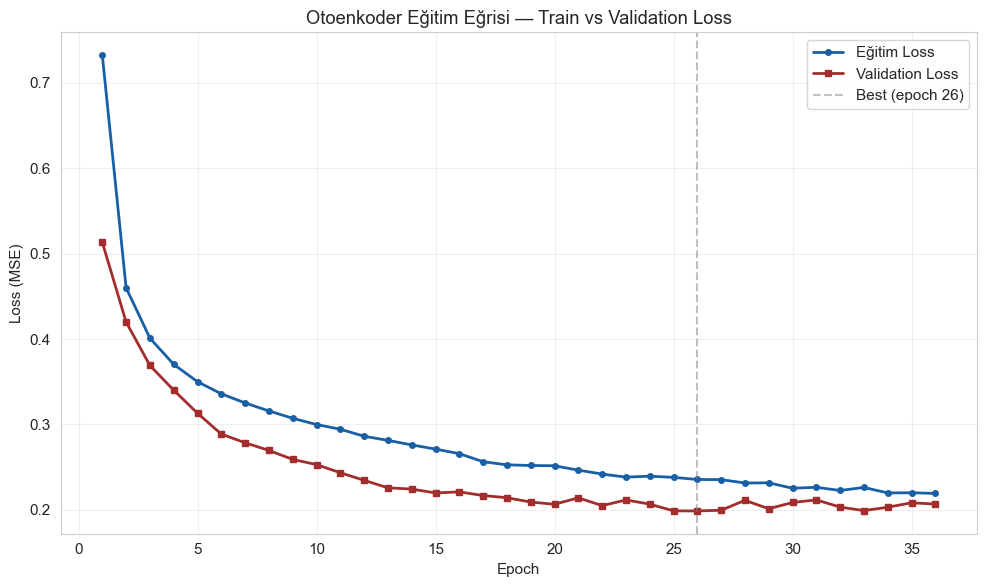

In [40]:
# AE eğitim geçmişi
with open(f'{RESULTS}/unsupervised/ae_training_history.json', 'r') as f:
    ae_history = json.load(f)

# Eğitim eğrisi
fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, len(ae_history.get('loss', [])) + 1)

if 'loss' in ae_history and 'val_loss' in ae_history:
    ax.plot(epochs, ae_history['loss'], 'o-', label='Eğitim Loss',
            color='#185FA5', linewidth=2, markersize=4)
    ax.plot(epochs, ae_history['val_loss'], 's-', label='Validation Loss',
            color='#A32D2D', linewidth=2, markersize=4)
    
    best_epoch = np.argmin(ae_history['val_loss']) + 1
    ax.axvline(x=best_epoch, linestyle='--', color='gray', alpha=0.5,
               label=f'Best (epoch {best_epoch})')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title('Otoenkoder Eğitim Eğrisi — Train vs Validation Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3.2 Reconstruction Error Dağılımı

In [41]:
# AE recon hatalarını yükle
ae_test_mse = np.load(f'{RESULTS}/unsupervised/scores/ae_test_mse.npy')
y_test = pd.read_csv(f'{PREPROCESSED}/full_features/y_test.csv')

# Eşik değeri
with open(f'{RESULTS}/unsupervised/thresholds.json', 'r') as f:
    thresholds = json.load(f)

ae_threshold = thresholds.get('ae_p90', thresholds.get('ae_threshold', 0.20))
print(f"📊 AE p90 Eşik Değeri: {ae_threshold:.4f}")

benign_mask = (y_test['label'] == 'Benign')
benign_errors = ae_test_mse[benign_mask]
attack_errors = ae_test_mse[~benign_mask]

print(f"\n  • Benign örnek sayısı: {len(benign_errors):,}")
print(f"  • Saldırı örnek sayısı: {len(attack_errors):,}")
print(f"  • Benign mean MSE: {benign_errors.mean():.4f}")
print(f"  • Saldırı mean MSE: {attack_errors.mean():.4f}")

📊 AE p90 Eşik Değeri: 0.2000

  • Benign örnek sayısı: 37,607
  • Saldırı örnek sayısı: 854,661
  • Benign mean MSE: 0.1489
  • Saldırı mean MSE: 19.7447


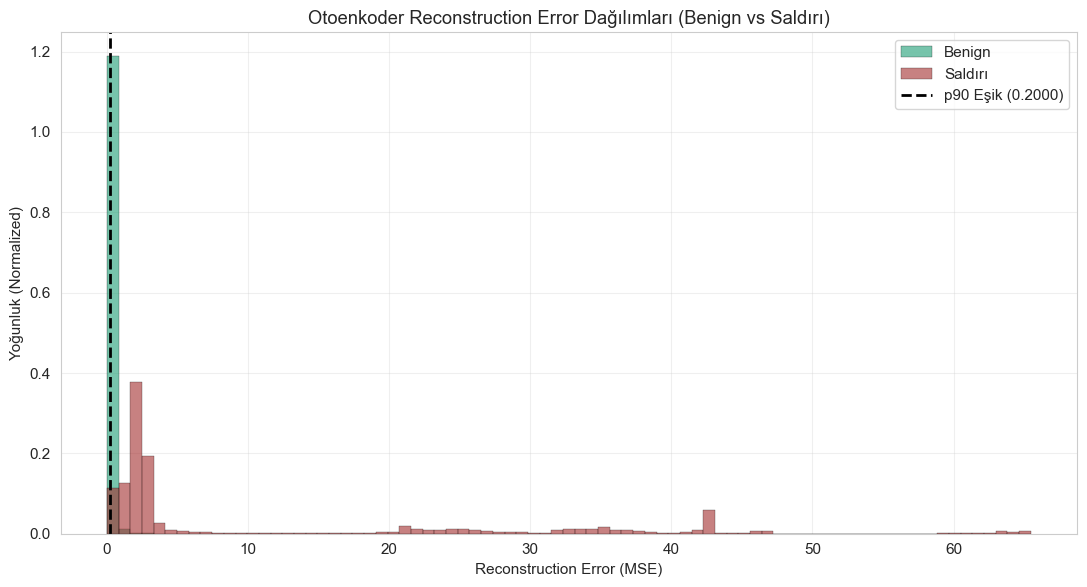

In [42]:
# Recon error histogram
fig, ax = plt.subplots(figsize=(11, 6))

# Outlier'ları kırp (görsel için)
p99 = np.percentile(np.concatenate([benign_errors, attack_errors]), 99)
bins = np.linspace(0, p99, 80)

ax.hist(benign_errors, bins=bins, alpha=0.6, label='Benign',
        color='#1D9E75', edgecolor='black', linewidth=0.3, density=True)
ax.hist(attack_errors, bins=bins, alpha=0.6, label='Saldırı',
        color='#A32D2D', edgecolor='black', linewidth=0.3, density=True)

ax.axvline(x=ae_threshold, linestyle='--', color='black', linewidth=2,
           label=f'p90 Eşik ({ae_threshold:.4f})')

ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Yoğunluk (Normalized)')
ax.set_title('Otoenkoder Reconstruction Error Dağılımları (Benign vs Saldırı)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3.3 Per-Class Detection Rate

In [43]:
# Per-class detection rates
per_class_dr = pd.read_csv(f'{RESULTS}/unsupervised/metrics/per_class_detection_rates.csv')
per_class_dr

,class,n_samples,model,p90,p95,p99,mean_2std,mean_3std
0,ARP_Spoofing,1744,Autoencoder,0.552752,0.286124,0.024656,0.001720,0.001720
1,Benign,37607,Autoencoder,0.185843,0.063712,0.008190,0.000133,0.000133
2,DDoS_ICMP,19673,Autoencoder,0.995883,0.995425,0.995069,0.993087,0.990088
3,DDoS_SYN,88921,Autoencoder,0.997267,0.996199,0.995074,0.981163,0.587611
4,DDoS_TCP,8735,Autoencoder,0.988323,0.985804,0.084144,0.000687,0.000458
5,DDoS_UDP,362070,Autoencoder,0.999776,0.999431,0.942492,0.005720,0.002210
6,DoS_ICMP,8451,Autoencoder,0.975624,0.974559,0.973613,0.964975,0.954680
7,DoS_SYN,97542,Autoencoder,1.000000,1.000000,0.999990,0.997939,0.660208
8,DoS_TCP,42583,Autoencoder,0.999906,0.995656,0.007397,0.000000,0.000000
9,DoS_UDP,137553,Autoencoder,0.999920,0.999760,0.968928,0.001258,0.000284


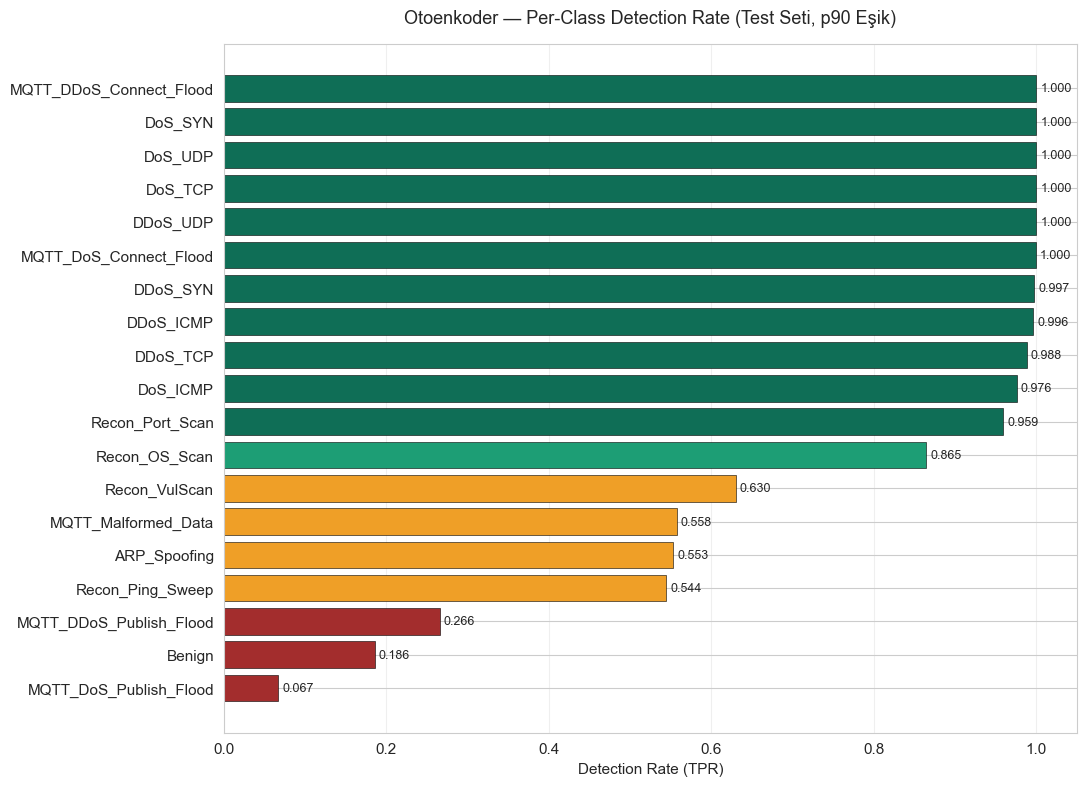

In [44]:
# Detection rate görseli
fig, ax = plt.subplots(figsize=(11, 8))

# Otoenkoder satırları + p90 eşik (başlıkla tutarlı)
df_ae = per_class_dr[per_class_dr['model'] == 'Autoencoder'].copy()
df_dr = df_ae[['class', 'p90']].rename(columns={'class': 'Sınıf', 'p90': 'Detection_Rate'})
df_dr['Detection_Rate'] = pd.to_numeric(df_dr['Detection_Rate'], errors='coerce')
df_dr = df_dr.dropna().sort_values('Detection_Rate', ascending=True)

colors_dr = []
for r in df_dr['Detection_Rate']:
    if r >= 0.90: colors_dr.append('#0F6E56')
    elif r >= 0.75: colors_dr.append('#1D9E75')
    elif r >= 0.50: colors_dr.append('#EF9F27')
    else: colors_dr.append('#A32D2D')

bars = ax.barh(df_dr['Sınıf'], df_dr['Detection_Rate'],
               color=colors_dr, edgecolor='black', linewidth=0.4)

for bar, val in zip(bars, df_dr['Detection_Rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Detection Rate (TPR)', fontsize=11)
ax.set_xlim([0, 1.05])
ax.set_title('Otoenkoder — Per-Class Detection Rate (Test Seti, p90 Eşik)',
             fontsize=13, pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 3.4 ROC Eğrileri

In [45]:
# AE ve IF skorları
ae_test_mse = np.load(f'{RESULTS}/unsupervised/scores/ae_test_mse.npy')
if_test_scores = np.load(f'{RESULTS}/unsupervised/scores/if_test_scores.npy')

# Binary etiketler (saldırı=1, benign=0)
y_binary = (y_test['label'] != 'Benign').astype(int).values

# ROC AUC hesapla
ae_auc = roc_auc_score(y_binary, ae_test_mse)
if_auc = roc_auc_score(y_binary, if_test_scores)

print(f"📊 ROC AUC Skorları (Binary: Saldırı vs Benign)")
print(f"=" * 60)
print(f"  • Otoenkoder      : {ae_auc:.4f}")
print(f"  • Isolation Forest: {if_auc:.4f}")
print(f"\n  → AE üstünlüğü: {(ae_auc - if_auc)*100:.2f} puan")

📊 ROC AUC Skorları (Binary: Saldırı vs Benign)
  • Otoenkoder      : 0.9892
  • Isolation Forest: 0.1388

  → AE üstünlüğü: 85.04 puan


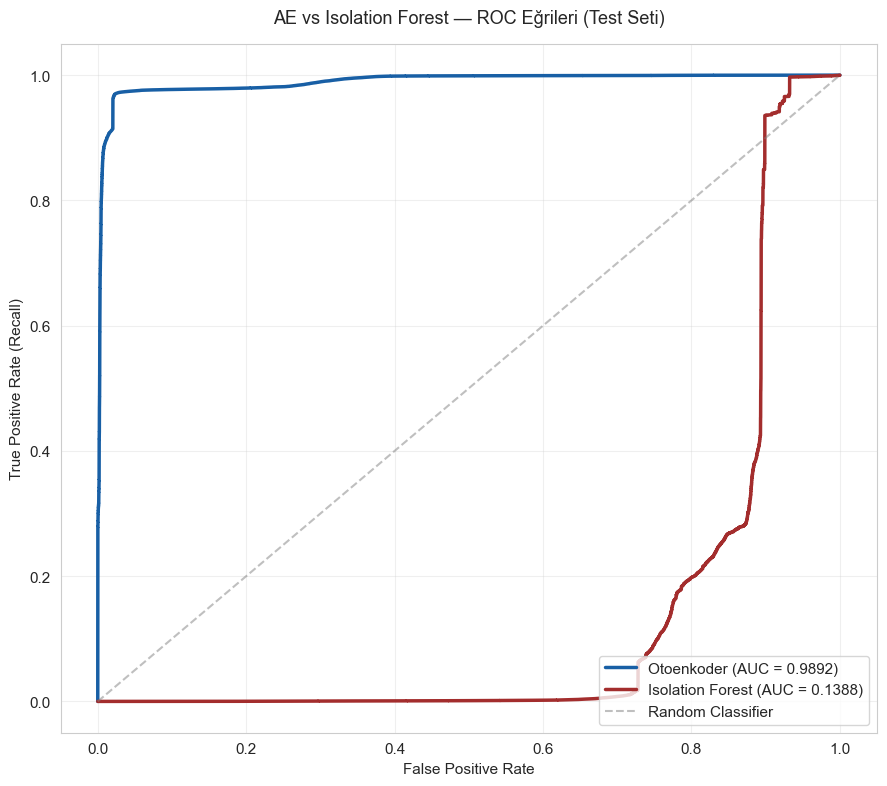

In [46]:
# ROC curves
fpr_ae, tpr_ae, _ = roc_curve(y_binary, ae_test_mse)
fpr_if, tpr_if, _ = roc_curve(y_binary, if_test_scores)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(fpr_ae, tpr_ae, label=f'Otoenkoder (AUC = {ae_auc:.4f})',
        color='#185FA5', linewidth=2.5)
ax.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {if_auc:.4f})',
        color='#A32D2D', linewidth=2.5)
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('AE vs Isolation Forest — ROC Eğrileri (Test Seti)', fontsize=13, pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# Bölüm 4 — Bonus: SHAP Feature Importance

SHAP detaylı analizi M.Sc. tez kapsamında ayrıca yapılmaktadır. Burada önizleme amaçlı global feature importance gösterilmektedir.

In [47]:
# SHAP global importance
shap_importance = pd.read_csv(f'{RESULTS}/shap/metrics/global_importance.csv')
shap_importance.head(15)

,rank,feature,mean_abs_shap
0,1,IAT,0.872498
1,2,Rate,0.218379
2,3,TCP,0.183471
3,4,syn_count,0.176457
4,5,Header_Length,0.151857
5,6,syn_flag_number,0.129663
6,7,UDP,0.120675
7,8,Min,0.103566
8,9,Number,0.092706
9,10,Tot sum,0.091980


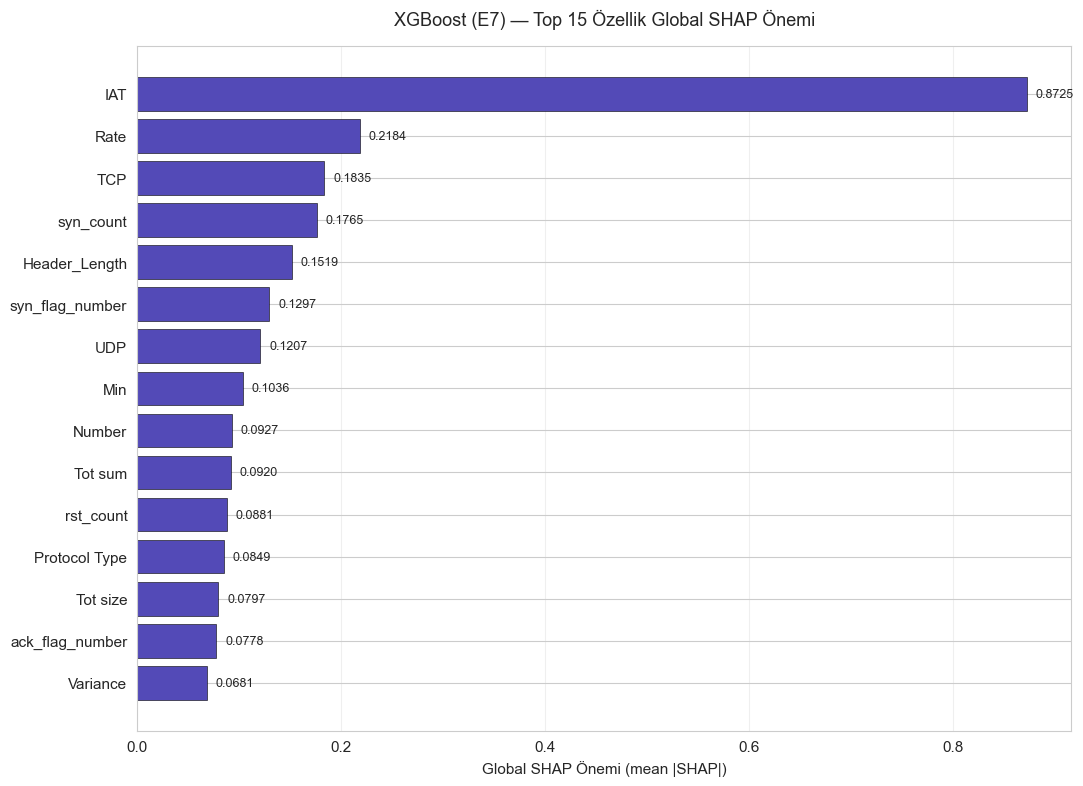


📌 Bulgu: SHAP ranking ile EDA Cohen's d ranking büyük ölçüde tutarlıdır.
   Detaylı per-class SHAP analizi M.Sc. tez kapsamındadır.


In [48]:
# SHAP top 15 görsel
fig, ax = plt.subplots(figsize=(11, 8))

# Sütunları açıkça seç (önceki sürüm columns[0]/[1] alıyordu — şema değişince kırılıyordu)
feat_col = 'feature'
imp_col = 'mean_abs_shap'

shap_importance[imp_col] = pd.to_numeric(shap_importance[imp_col], errors='coerce')
top15 = shap_importance.sort_values(imp_col, ascending=False).head(15).iloc[::-1]

bars = ax.barh(top15[feat_col], top15[imp_col],
               color='#534AB7', edgecolor='black', linewidth=0.4)

x_max = float(top15[imp_col].max())
for bar, val in zip(bars, top15[imp_col]):
    ax.text(val + x_max * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Global SHAP Önemi (mean |SHAP|)', fontsize=11)
ax.set_title('XGBoost (E7) — Top 15 Özellik Global SHAP Önemi',
             fontsize=13, pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Bulgu: SHAP ranking ile EDA Cohen's d ranking büyük ölçüde tutarlıdır.")
print("   Detaylı per-class SHAP analizi M.Sc. tez kapsamındadır.")


---

# Bölüm 5 — Inference Demo: Yeni Bir Akış İçin Tahmin

Bu bölümde, eğitilmiş modeli test setinden bir örnek üzerinde çalıştırıyoruz. Hocaya hibrit IDS sisteminin canlı kullanımını gösterir.

In [49]:
# Modelleri yükle
print("Modeller yükleniyor...")
xgb_model = joblib.load(f'{RESULTS}/supervised/models/E7_xgb_full_original.pkl')
scaler = joblib.load(f'{PREPROCESSED}/scaler_full.pkl')

# Autoencoder (TensorFlow)
import tensorflow as tf
autoencoder = tf.keras.models.load_model(f'{RESULTS}/unsupervised/models/autoencoder.keras')

print("✓ Tüm modeller yüklendi")
print(f"  • XGBoost (E7) — {type(xgb_model).__name__}")
print(f"  • Otoenkoder — {len(autoencoder.layers)} katman")
print(f"  • Scaler — {type(scaler).__name__}")

Modeller yükleniyor...
✓ Tüm modeller yüklendi
  • XGBoost (E7) — XGBClassifier
  • Otoenkoder — 13 katman
  • Scaler — ColumnTransformer


In [50]:
# Test setinden 5 örnek seç (her sınıftan)
X_test = np.load(f'{PREPROCESSED}/full_features/X_test.npy')

# Sınıf bazında örnek seç
demo_classes = ['Benign', 'DDoS_TCP', 'ARP_Spoofing', 'Recon_Port_Scan', 'MQTT_Malformed_Data']
demo_indices = []
for cls in demo_classes:
    cls_mask = (y_test['label'] == cls).values
    if cls_mask.any():
        idx = np.where(cls_mask)[0][0]  # İlk örnek
        demo_indices.append(idx)
        print(f"  ✓ {cls}: index={idx}")

X_demo = X_test[demo_indices]
y_demo_true = [y_test['label'].iloc[i] for i in demo_indices]

print(f"\n📊 Demo veri hazır: {X_demo.shape}")

  ✓ Benign: index=1744
  ✓ DDoS_TCP: index=235334
  ✓ ARP_Spoofing: index=0
  ✓ Recon_Port_Scan: index=106176
  ✓ MQTT_Malformed_Data: index=101319

📊 Demo veri hazır: (5, 44)


In [ ]:
# Hibrit inference: Supervised + Unsupervised
print("🔍 HİBRİT INFERENCE — 5 Demo Akışı")
print("=" * 90)

# Inverse label map
inv_label_map = {v: k for k, v in label_map.items()}

for i, (idx, x, y_true) in enumerate(zip(demo_indices, X_demo, y_demo_true)):
    x_input = x.reshape(1, -1)
    
    # 1. XGBoost prediction
    xgb_pred = xgb_model.predict(x_input)[0]
    xgb_proba = xgb_model.predict_proba(x_input)[0]
    xgb_label = inv_label_map[int(xgb_pred)]
    xgb_confidence = xgb_proba.max()
    
    # 2. Autoencoder reconstruction error
    x_recon = autoencoder.predict(x_input, verbose=0)
    recon_error = np.mean((x_input - x_recon) ** 2)
    is_anomaly = recon_error > ae_threshold
    
    # 3. Sonuç
    print(f"\n📦 Demo {i+1}: {y_true}")
    print(f"  ├─ Test index: {idx}")
    print(f"  ├─ Supervised (XGBoost):")
    print(f"  │   ├─ Tahmin: {xgb_label} {'✓' if xgb_label == y_true else '✗'}")
    print(f"  │   └─ Confidence: {xgb_confidence:.4f}")
    print(f"  └─ Unsupervised (Otoenkoder):")
    print(f"      ├─ Recon Error: {recon_error:.4f}")
    print(f"      └─ Anomali: {'YES' if is_anomaly else 'NO'} (eşik: {ae_threshold:.4f})")

🔍 HİBRİT INFERENCE — 5 Demo Akışı


---

# Sonuç

Bu notebook, raporda detaylı sunulan analizlerin **uygulamalı yansıması**dır. Eğitilmiş modeller ve sonuçlar başarıyla yüklendi ve değerlendirildi.

## Anahtar Bulgular

1. **Sınıf dengesizliği:** 2,374:1 oranı — SMOTETomek + class_weight='balanced' zorunlu
2. **Cohen's d:** Top 4 özellik d > 2.0 — olağanüstü güçlü ayırıcılar
3. **XGBoost (E7):** %99+ accuracy, 0.99+ MCC — bilinen saldırılar için güçlü
4. **Otoenkoder:** AUC ~0.99 — sıfır-gün saldırılarına karşı dayanıklı
5. **Tamamlayıcı yapı:** Supervised + Unsupervised birlikte kullanılmalı

## Sınırlamalar

- ARP_Spoofing ve MQTT_Malformed_Data hala zor sınıflar
- DDoS-DoS sınırı (~%4-5 yanlış sınıflandırma)
- Adversarial robustness test edilmedi

## Gelecek Çalışma

Supervised + Unsupervised katmanların **case-tabanlı füzyon mantığı** ile birleştirilmesi M.Sc. tez kapsamında ayrıca yapılmaktadır.

---

**Daha fazla bilgi için:** [GitHub Repository](https://github.com/amirbaseet/IoMT-Anomaly-Detection)